In [ ]:
%pip install -q torch torchaudio soundfile encodec numpy matplotlib

In [3]:
import os, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import soundfile as sf

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [27]:
import soundfile as sf
import numpy as np
import torch

wav_path = "gapped_audio.wav"

audio, sr = sf.read(wav_path, always_2d=True)  # shape [T, C]
audio = audio.astype(np.float32)

# to mono
audio = audio.mean(axis=1)  # [T]

# to torch [1, T]
wav = torch.from_numpy(audio).unsqueeze(0)

print("Loaded:", wav_path)
print("wav:", tuple(wav.shape), "sr:", sr, "seconds:", wav.shape[-1]/sr)

Loaded: gapped_audio.wav
wav: (1, 6402731) sr: 16000 seconds: 400.1706875


In [28]:
import librosa

target_sr = 24000

wav_np = wav.squeeze(0).numpy()
if sr != target_sr:
    wav_np = librosa.resample(wav_np, orig_sr=sr, target_sr=target_sr)
    sr = target_sr

# back to torch [1, T]
wav = torch.from_numpy(wav_np).unsqueeze(0)

# normalize
wav = wav / (wav.abs().max() + 1e-9)

print("Resampled wav:", tuple(wav.shape), "sr:", sr)

Resampled wav: (1, 9604097) sr: 24000


In [29]:
import soundfile as sf

sf.write("resampled_24k.wav", wav.squeeze(0).numpy(), sr)
print("Saved: resampled_24k.wav")

Saved: resampled_24k.wav


In [30]:
# TODO: set your gap boundaries (seconds)
duration_s = wav.shape[-1] / target_sr
#3:20 -> 3:30
gap_start_s = 3*60 + 20
gap_end_s   = 3*60 + 30
assert 0 <= gap_start_s < gap_end_s <= duration_s

gap_start_sample = int(gap_start_s * target_sr)
gap_end_sample   = int(gap_end_s   * target_sr)

print("Gap samples:", gap_start_sample, gap_end_sample, "len(s):", (gap_end_sample-gap_start_sample)/target_sr)

Gap samples: 4800000 5040000 len(s): 10.0


In [31]:
from encodec import EncodecModel

codec = EncodecModel.encodec_model_24khz().to(device).eval()
codec.set_target_bandwidth(6.0)

with torch.no_grad():
    x = wav.to(device).unsqueeze(0)  # [1, 1, T]
    encoded = codec.encode(x)

codes_b, scale = encoded[0]          # codes_b: [B, K, frames] int64
codes = codes_b[0].detach().cpu()    # [K, frames]
K, frames = codes.shape

bins = int(codec.quantizer.bins)     # usually 1024
mask_token = bins                    # reserve id bins as [MASK]

print("codes:", tuple(codes.shape), "K:", K, "frames:", frames, "bins:", bins)

/export/livia/home/vision/Fbassignana/miniconda3/envs/research-project/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


codes: (8, 30013) K: 8 frames: 30013 bins: 1024


In [32]:
encoded[0][0].dtype

torch.int64

In [33]:
# frames per second in the EnCodec token stream
fps = frames / duration_s
gap_start_f = int(round(gap_start_s * fps))
gap_end_f   = int(round(gap_end_s   * fps))

gap_start_f = max(0, min(frames, gap_start_f))
gap_end_f   = max(0, min(frames, gap_end_f))
assert gap_start_f < gap_end_f

print("fps:", fps)
print("Gap frames:", gap_start_f, gap_end_f, "len(frames):", gap_end_f-gap_start_f, "len(s):", (gap_end_f-gap_start_f)/fps)

fps: 75.00049197753833
Gap frames: 15000 15750 len(frames): 750 len(s): 9.999934403425183


In [34]:
import random
import torch

class NonGapMaskedSpanDataset(torch.utils.data.Dataset):
    def __init__(self, codes_KF: torch.Tensor, gap_f0: int, gap_f1: int,
                 seq_len=1024, mask_len_range=(64, 256), mask_token=1024):
        """
        codes_KF: [K, F] int64
        gap_f0, gap_f1: gap frame interval [gap_f0, gap_f1)
        seq_len: window length in frames
        mask_len_range: random mask length in frames (inclusive)
        mask_token: token id used to mask (should be bins)
        """
        self.codes = codes_KF
        self.K, self.F = codes_KF.shape
        self.g0, self.g1 = gap_f0, gap_f1
        self.seq_len = seq_len
        self.mask_len_range = mask_len_range
        self.mask_token = mask_token

        assert 0 <= self.g0 < self.g1 <= self.F
        assert self.F > seq_len + 1

        # Allowed start positions where window [s, s+seq_len) does NOT intersect gap
        # Non-intersect means: s+seq_len <= g0 OR s >= g1
        self.starts = []
        max_s = self.F - self.seq_len
        for s in range(0, max_s):
            if (s + self.seq_len) <= self.g0 or s >= self.g1:
                self.starts.append(s)

        assert len(self.starts) > 0, "No valid windows found. Reduce seq_len or check gap."

    def __len__(self):
        return 50000  # virtual length; we sample randomly

    def __getitem__(self, idx):
        s = random.choice(self.starts)
        x = self.codes[:, s:s+self.seq_len].clone()  # [K, T]
        y = x.clone()

        mask_len = random.randint(self.mask_len_range[0], self.mask_len_range[1])
        mask_len = min(mask_len, self.seq_len)
        m0 = random.randint(0, self.seq_len - mask_len)
        m1 = m0 + mask_len

        x[:, m0:m1] = self.mask_token

        loss_mask = torch.zeros(self.seq_len, dtype=torch.bool)
        loss_mask[m0:m1] = True

        return x, y, loss_mask

seq_len = 1024
mask_len_range = (64, 256)

ds = NonGapMaskedSpanDataset(
    codes_KF=codes,
    gap_f0=gap_start_f,
    gap_f1=gap_end_f,
    seq_len=seq_len,
    mask_len_range=mask_len_range,
    mask_token=mask_token,
)

dl = torch.utils.data.DataLoader(
    ds,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)

print("K,F:", tuple(codes.shape))
print("valid starts:", len(ds.starts))

K,F: (8, 30013)
valid starts: 27216


In [35]:
import torch.nn as nn

class JointCodebookInfiller(nn.Module):
    def __init__(self, K, bins, d_model=512, n_heads=8, n_layers=8, max_len=2048, dropout=0.1):
        super().__init__()
        self.K = K
        self.bins = bins
        self.vocab = bins + 1  # + [MASK]

        self.emb = nn.ModuleList([nn.Embedding(self.vocab, d_model) for _ in range(K)])
        self.pos = nn.Embedding(max_len, d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        self.head = nn.ModuleList([nn.Linear(d_model, bins) for _ in range(K)])

    def forward(self, x):
        """
        x: [B, K, T] int64 tokens in [0..bins-1] or [MASK]=bins
        returns logits: [B, K, T, bins]
        """
        B, K, T = x.shape
        assert K == self.K
        pos = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)

        h = self.pos(pos)  # [B, T, D]
        for k in range(K):
            h = h + self.emb[k](x[:, k, :])  # [B, T, D]

        h = self.enc(h)  # [B, T, D]
        logits = torch.stack([self.head[k](h) for k in range(K)], dim=1)  # [B, K, T, bins]
        return logits

K = codes.shape[0]
net = JointCodebookInfiller(K=K, bins=bins, max_len=2048).cuda()
print("model params:", sum(p.numel() for p in net.parameters())/1e6, "M")

model params: 34.668544 M


/tmp/ipykernel_1758595/2250340432.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc = nn.TransformerEncoder(enc_layer, num_layers=n_layers)


In [36]:
import torch

opt = torch.optim.AdamW(net.parameters(), lr=2e-4, weight_decay=1e-2, betas=(0.9, 0.95))
scaler = torch.amp.GradScaler()

In [37]:
import time
import torch.nn.functional as F
import torch

def train(steps=3000, log_every=100):
    net.train()
    t0 = time.time()
    running = 0.0

    it = iter(dl)
    for step in range(1, steps + 1):
        try:
            x, y, loss_mask = next(it)
        except StopIteration:
            it = iter(dl)
            x, y, loss_mask = next(it)

        x = x.cuda(non_blocking=True)
        y = y.cuda(non_blocking=True)
        loss_mask = loss_mask.cuda(non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            logits = net(x)  # [B, K, T, bins]

            if loss_mask.dim() == 1:
                loss_mask_bt = loss_mask.unsqueeze(0).expand(x.size(0), -1)
            else:
                loss_mask_bt = loss_mask
            loss_mask_bt = loss_mask_bt.bool()

            B, K, T, V = logits.shape
            logits_flat = logits.permute(0, 2, 1, 3).reshape(B*T*K, V)
            y_flat      = y.permute(0, 2, 1).reshape(B*T*K)

            mask_flat_bt = loss_mask_bt.reshape(B*T)
            mask_flat_btk = mask_flat_bt.repeat_interleave(K)

            logits_sel = logits_flat[mask_flat_btk]
            y_sel = y_flat[mask_flat_btk]

            loss = F.cross_entropy(logits_sel, y_sel)

        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        scaler.step(opt)
        scaler.update()

        running += float(loss.item())
        if step % log_every == 0:
            dt = time.time() - t0
            print(f"step {step:5d} | loss {running/log_every:.4f} | {dt:.1f}s")
            running = 0.0
            t0 = time.time()

In [38]:
train(steps=1000, log_every=100)

step   100 | loss 6.0317 | 33.9s
step   200 | loss 5.7097 | 34.5s
step   300 | loss 5.6393 | 35.1s
step   400 | loss 5.5450 | 35.3s
step   500 | loss 5.4535 | 34.9s
step   600 | loss 5.4732 | 34.9s
step   700 | loss 5.3682 | 34.8s
step   800 | loss 5.3464 | 34.9s
step   900 | loss 5.3532 | 35.0s
step  1000 | loss 5.2760 | 35.3s


max_len: 2048
gap_len: 750
using ctx_left/right: 641 641
total T: 2032


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [41]:
@torch.no_grad()
def inpaint_gap_joint(
    codes_KF: torch.Tensor,
    gap_f0: int,
    gap_f1: int,
    ctx_left: int = 2048,
    ctx_right: int = 2048,
    iters: int = 8,
):
    """
    codes_KF: [K, F] int64 on CPU
    returns codes_filled: [K, F] int64 on CPU
    """
    net.eval()
    K, F = codes_KF.shape

    codes_filled = codes_KF.clone()

    L = max(0, gap_f0 - ctx_left)
    R = min(F, gap_f1 + ctx_right)
    T = R - L

    g0 = gap_f0 - L
    g1 = gap_f1 - L

    # [1, K, T]
    x = codes_filled[:, L:R].clone()
    x[:, g0:g1] = mask_token
    xb = x.unsqueeze(0).cuda()

    for _ in range(iters):
        logits = net(xb)[0]            # [K, T, bins]
        pred = logits.argmax(dim=-1)   # [K, T]
        xb[0, :, g0:g1] = pred[:, g0:g1]

    codes_filled[:, L:R] = xb[0].cpu()
    return codes_filled

max_len = net.pos.num_embeddings  # e.g. 2048
gap_len = gap_end_f - gap_start_f

# leave some margin
budget = max_len - gap_len - 16
budget = max(0, budget)

ctx_left = budget // 2
ctx_right = budget - ctx_left

print("max_len:", max_len)
print("gap_len:", gap_len)
print("using ctx_left/right:", ctx_left, ctx_right)
print("total T:", gap_len + ctx_left + ctx_right)

codes_filled = inpaint_gap_joint(
    codes, gap_start_f, gap_end_f,
    ctx_left=ctx_left, ctx_right=ctx_right,
    iters=10
)

max_len: 2048
gap_len: 750
using ctx_left/right: 641 641
total T: 2032


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
import soundfile as sf
import os

with torch.no_grad():
    codes_b = codes_filled.unsqueeze(0).cuda()  # [1, K, F]
    filled_encoded = [(codes_b, scale)]
    wav_filled = codec.decode(filled_encoded).squeeze(0).cpu().squeeze(0).numpy()

out_path = os.path.splitext(wav_path)[0] + "_encodec_transformer_inpaint.wav"
sf.write(out_path, wav_filled, target_sr)
print("Saved:", out_path)

# RAVE VAE

In [24]:
import os
import numpy as np
import torch
import torchaudio
import soundfile as sf
import matplotlib.pyplot as plt
import requests

print("torch:", torch.__version__)
print("torchaudio:", torchaudio.__version__)

device_preferred = "mps" if torch.backends.mps.is_available() else "cpu"
print("preferred device:", device_preferred)

torch: 2.10.0
torchaudio: 2.10.0
preferred device: mps


In [25]:
# Pretrained RAVE model (TorchScript .ts)
# Listed in Intelligent-Instruments-Lab/rave-models README as:
# mrp_strengjavera_b2048_r44100_z16.ts (44.1kHz, block=2048)
model_url = "https://huggingface.co/Intelligent-Instruments-Lab/rave-models/resolve/main/mrp_strengjavera_b2048_r44100_z16.ts"
model_path = "mrp_strengjavera_b2048_r44100_z16.ts"

if not os.path.exists(model_path):
    print("Downloading model...")
    r = requests.get(model_url, stream=True)
    r.raise_for_status()
    with open(model_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

print("Model file:", model_path, "size (MB):", os.path.getsize(model_path)/1e6)

Model file: mrp_strengjavera_b2048_r44100_z16.ts size (MB): 150.041064


In [27]:
wav_path = "wav_test.wav"
assert os.path.exists(wav_path), f"File not found: {wav_path}"

wav, sr = torchaudio.load(wav_path)  # [C, T]
print("Loaded:", wav_path)
print("Shape:", tuple(wav.shape), "Sample rate:", sr)
print("Duration (s):", wav.shape[-1] / sr)

Loaded: wav_test.wav
Shape: (2, 19208192) Sample rate: 48000
Duration (s): 400.17066666666665


In [28]:
target_sr = 44100

# mono
if wav.shape[0] > 1:
    wav = wav.mean(dim=0, keepdim=True)

# resample
if sr != target_sr:
    wav = torchaudio.transforms.Resample(sr, target_sr)(wav)

# normalize
wav = wav / (wav.abs().max() + 1e-9)

print("Preprocessed shape:", tuple(wav.shape), "sr:", target_sr)

Preprocessed shape: (1, 17647526) sr: 44100


In [29]:
rave = torch.jit.load(model_path).eval()

def try_to_device(ts_model, device):
    try:
        return ts_model.to(device), device
    except Exception as e:
        print(f"Could not move TorchScript model to {device}: {type(e).__name__}: {e}")
        return ts_model.to("cpu"), "cpu"

rave, device = try_to_device(rave, device_preferred)
print("Using device:", device)

# Inspect available methods (TorchScript modules expose methods/attributes variably)
print("TorchScript model type:", type(rave))
print("Has forward:", hasattr(rave, "forward"))

Using device: mps
TorchScript model type: <class 'torch.jit._script.RecursiveScriptModule'>
Has forward: True


In [30]:
with torch.no_grad():
    x = wav.unsqueeze(0).to(device)  # [B=1, C=1, T]
    
    # Make length a multiple of block size (2048) for streaming-style models
    block = 2048
    T = x.shape[-1]
    pad = (block - (T % block)) % block
    if pad > 0:
        x = torch.nn.functional.pad(x, (0, pad))
    
    # Try encode/decode path first
    if hasattr(rave, "encode") and hasattr(rave, "decode"):
        z = rave.encode(x)
        x_rec = rave.decode(z)
        print("Used encode/decode. z dtype:", z.dtype, "z shape:", tuple(z.shape))
    else:
        # Fallback: forward
        out = rave(x)
        # Some models return tuple/list; handle common cases
        if isinstance(out, (tuple, list)):
            x_rec = out[0]
        else:
            x_rec = out
        print("Used forward(). Output shape:", tuple(x_rec.shape))

# Remove padding to original length
x_rec = x_rec[..., :T]
x_cpu = x.squeeze(0).cpu().squeeze(0).numpy()
x_rec_cpu = x_rec.squeeze(0).cpu().squeeze(0).numpy()

print("Original len:", x_cpu.shape[-1], "Recon len:", x_rec_cpu.shape[-1])

Used encode/decode. z dtype: torch.float32 z shape: (1, 8, 8617)
Original len: 17647616 Recon len: 17647526


In [31]:
out_wav_path = os.path.splitext(wav_path)[0] + "_recon_rave_mrp_44100.wav"
sf.write(out_wav_path, x_rec_cpu, target_sr)
print("Saved:", out_wav_path)

Saved: wav_test_recon_rave_mrp_44100.wav


In [32]:
eps = 1e-9
e = x_cpu - x_rec_cpu

mse = float(np.mean(e**2))
snr = 10.0 * np.log10((np.mean(x_cpu**2) + eps) / (np.mean(e**2) + eps))

alpha = np.dot(x_rec_cpu, x_cpu) / (np.dot(x_cpu, x_cpu) + eps)
e_si = x_rec_cpu - alpha * x_cpu
si_sdr = 10.0 * np.log10((np.mean((alpha * x_cpu)**2) + eps) / (np.mean(e_si**2) + eps))

print(f"MSE:    {mse:.6e}")
print(f"SNR:    {snr:.2f} dB")
print(f"SI-SDR: {si_sdr:.2f} dB (basic)")

ValueError: operands could not be broadcast together with shapes (17647616,) (17647526,) 

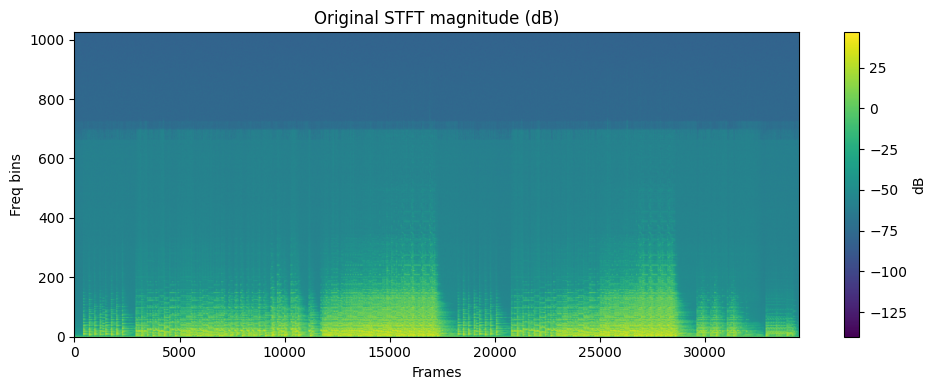

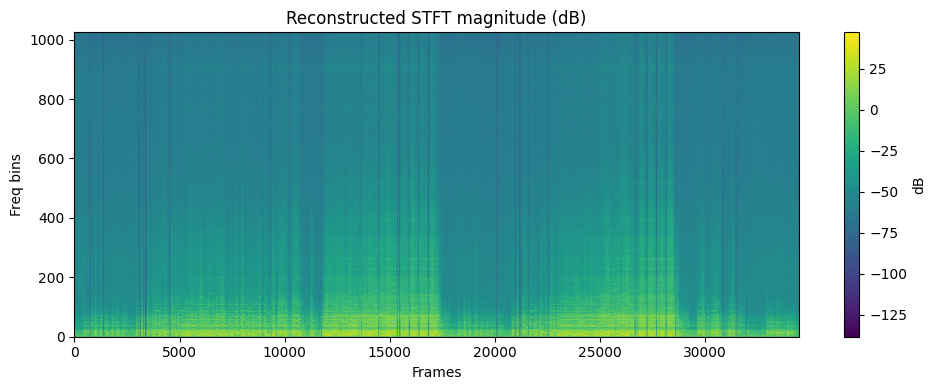

In [33]:
def stft_mag(y, n_fft=2048, hop=512):
    y_t = torch.tensor(y, dtype=torch.float32)
    S = torch.stft(y_t, n_fft=n_fft, hop_length=hop, win_length=n_fft,
                   window=torch.hann_window(n_fft), return_complex=True)
    return torch.abs(S).numpy()

S_orig = stft_mag(x_cpu)
S_reco = stft_mag(x_rec_cpu)

def show_spec(S, title):
    S_db = 20*np.log10(S + 1e-7)
    plt.figure(figsize=(10,4))
    plt.imshow(S_db, origin="lower", aspect="auto")
    plt.title(title)
    plt.colorbar(label="dB")
    plt.xlabel("Frames")
    plt.ylabel("Freq bins")
    plt.tight_layout()
    plt.show()

show_spec(S_orig, "Original STFT magnitude (dB)")
show_spec(S_reco, "Reconstructed STFT magnitude (dB)")